# Support Vector Machines - Einführung

In diesem Kapitel erforschen wir die Grundlagen der SVM und ihre Anwendung auf Klassifikationsaufgaben

## Wie werden Support Vector Machines trainiert?

Support Vector Machines (SVMs) werden trainiert, indem sie eine **optimale Hyperebene** finden, die Datenpunkte verschiedener Klassen im Merkmalsraum bestmöglich voneinander trennt. Das Ziel ist es, den **Abstand (Margin)** zwischen der Hyperebene und den nächstgelegenen Datenpunkten beider Klassen zu maximieren. Diese nächstgelegenen Datenpunkte werden als **Stützvektoren (Support Vectors)** bezeichnet, da sie die Position und Orientierung der Hyperebene bestimmen.

Zusammenfassend lässt sich sagen, dass SVMs versuchen, die "beste" Trennlinie zu finden, indem sie den Abstand zwischen den Klassen maximieren, sich dabei auf die wichtigsten Datenpunkte (Stützvektoren) konzentrieren und bei Bedarf den Kernel-Trick nutzen, um auch nicht-lineare Trennungen zu ermöglichen.

## Hier sind die wichtigsten Schritte und Konzepte:

1.  **Lineare Trennung**: Für linear trennbare Daten sucht die SVM eine gerade Linie (in 2D), eine Ebene (in 3D) oder eine Hyperebene (in höherdimensionalen Räumen), die die Klassen ohne Überlappung trennt.

2.  **Maximierung des Abstands**: Unter allen möglichen Trennhyperebenen wählt die SVM diejenige, die den größten Abstand zu den nächstgelegenen Datenpunkten jeder Klasse aufweist. Dieser Abstand wird als Margin bezeichnet. Ein größerer Margin führt in der Regel zu einer besseren Generalisierungsfähigkeit des Modells.

3.  **Stützvektoren**: Die Datenpunkte, die auf oder innerhalb des Margins liegen und somit die Position der Hyperebene beeinflussen, sind die Stützvektoren. Nur diese Vektoren sind für die Definition der Hyperebene relevant; andere Datenpunkte haben keinen Einfluss.

4.  **Optimierungsproblem**: Das Finden der optimalen Hyperebene ist ein Optimierungsproblem, das typischerweise mit Techniken der quadratischen Programmierung gelöst wird.

5.  **Soft Margin (für nicht-lineare Fälle)**: In der Realität sind Daten oft nicht perfekt linear trennbar. SVMs verwenden hierfür den so genannten "Soft Margin"-Ansatz. Dabei erlaubt das Modell eine gewisse Fehlklassifizierung von Datenpunkten, indem es eine Straffunktion für Datenpunkte einführt, die den Margin verletzen oder falsch klassifiziert werden. Der Hyperparameter `C` steuert den Kompromiss zwischen einem großen Margin und wenigen Fehlklassifizierungen.

6.  **Kernel-Trick (für nicht-lineare Trennung)**: Wenn Daten nicht linear trennbar sind, kann der **Kernel-Trick** angewendet werden. Dabei werden die Datenpunkte in einen höherdimensionalen Merkmalsraum "abgebildet", in dem sie linear trennbar sind. Ohne die Datenpunkte explizit transformieren zu müssen, berechnen Kernel-Funktionen (z. B. der radiale Basisfunktions-Kernel (RBF), der polynomiale Kernel) Ähnlichkeiten zwischen den Datenpunkten im höherdimensionalen Raum. Dadurch kann die SVM auch komplexe, nicht-lineare Entscheidungsgrenzen lernen.


### SVM-Trainierung mit RBF-Kernel für nicht-linear trennbare Daten

Für nicht-linear trennbare Daten ist der Kernel-Trick unerlässlich. Hier verwenden wir den radialen Basisfunktions-Kernel (RBF), um die Daten in einen höherdimensionalen Raum abzubilden, in dem sie linear getrennt werden können. Wir generieren Daten, die konzentrische Kreise bilden, was ein klassisches Beispiel für nicht-linear trennbare Daten ist.

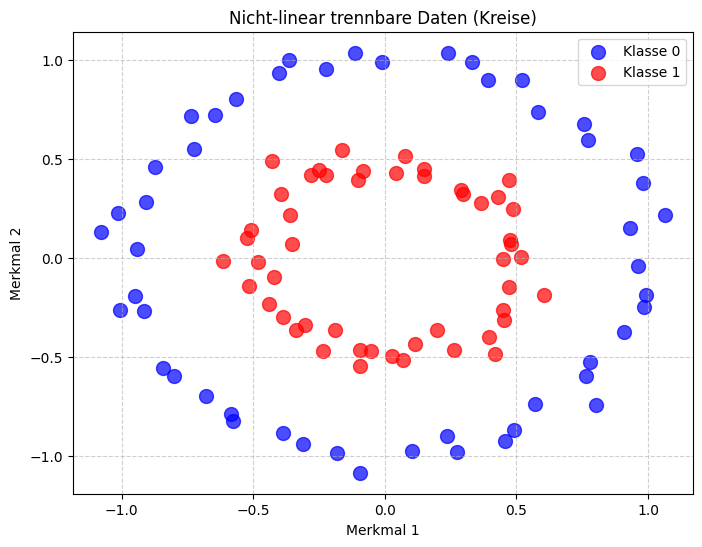

In [1]:
from sklearn.datasets import make_circles
from sklearn.svm import SVC
import matplotlib.pyplot as plt


# 1. Nicht-linear trennbare Daten generieren (konzentrische Kreise)
X_nl, y_nl = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=42)

# 2. Daten visualisieren
plt.figure(figsize=(8, 6))
plt.scatter(X_nl[y_nl == 0, 0], X_nl[y_nl == 0, 1], s=100, marker='o', alpha=0.7, c='blue', label='Klasse 0')
plt.scatter(X_nl[y_nl == 1, 0], X_nl[y_nl == 1, 1], s=100, marker='o', alpha=0.7, c='red', label='Klasse 1')
plt.xlabel('Merkmal 1')
plt.ylabel('Merkmal 2')
plt.title('Nicht-linear trennbare Daten (Kreise)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [2]:
# 3. SVC-Modell mit RBF-Kernel trainieren
model_rbf = SVC(kernel='rbf', C=1000, gamma=0.1) # C und gamma sind Hyperparameter für den RBF-Kernel
model_rbf.fit(X_nl, y_nl)

SVC(C=1000, gamma=0.1)

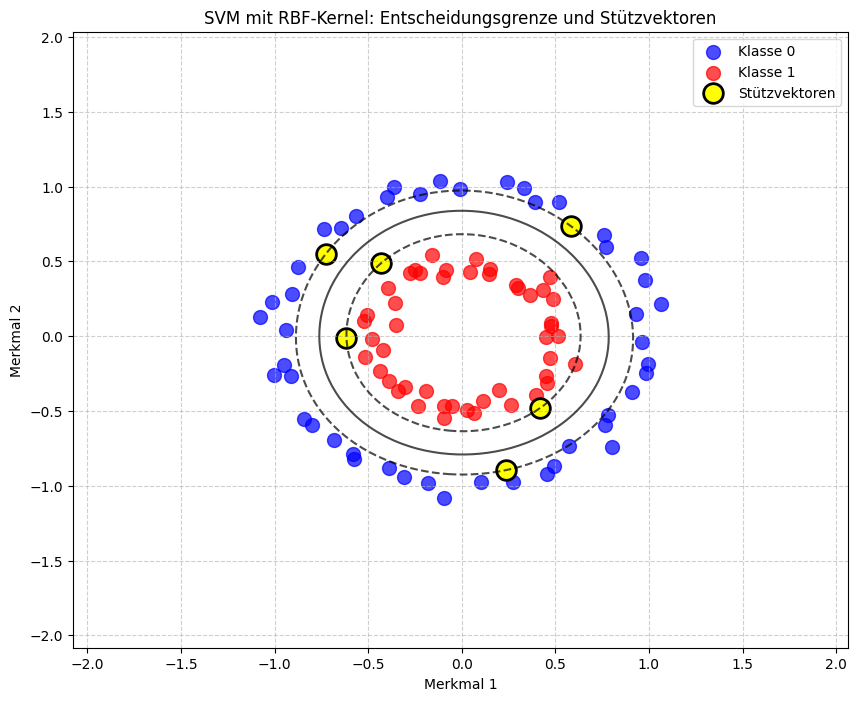

(<matplotlib.legend.Legend at 0x7d91900c5b50>, None, None)

In [3]:
# 4. Entscheidungsgrenze und Stützvektoren visualisieren
import numpy as np

plt.figure(figsize=(10, 8))
plt.scatter(X_nl[y_nl == 0, 0], X_nl[y_nl == 0, 1], s=100, marker='o', alpha=0.7, c='blue', label='Klasse 0')
plt.scatter(X_nl[y_nl == 1, 0], X_nl[y_nl == 1, 1], s=100, marker='o', alpha=0.7, c='red', label='Klasse 1')

# Erstellen eines Gitters zur Darstellung der Entscheidungsgrenze
x_min, x_max = X_nl[:, 0].min() - 1, X_nl[:, 0].max() + 1
y_min, y_max = X_nl[:, 1].min() - 1, X_nl[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Vorhersage für jeden Punkt im Gitter
Z = model_rbf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Entscheidungsgrenze und Margins zeichnen
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.7, linestyles=['--', '-', '--'])

# Stützvektoren hervorheben - visuell deutlicher dargestellt
plt.scatter(model_rbf.support_vectors_[:, 0], model_rbf.support_vectors_[:, 1],
            s=200, linewidth=2, facecolors='yellow', edgecolors='k', label='Stützvektoren') # Änderungen hier

plt.xlabel('Merkmal 1'), plt.ylabel('Merkmal 2')
plt.title('SVM mit RBF-Kernel: Entscheidungsgrenze und Stützvektoren')
plt.legend(), plt.grid(True, linestyle='--', alpha=0.6), plt.show()

# Motivation für SVMs

## Import Bibliotheken

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn to make its styles available
sns.set_style('whitegrid') # Use sns.set_style to apply seaborn styles
from scipy import stats

## Einfache Klassifizierungsaufgabe
Betrachten Sie als Beispiel hierfür den einfachen Fall einer Klassifizierungsaufgabe, bei der die beiden Klassen von Punkten gut voneinander getrennt sind (siehe folgende Abbildung):

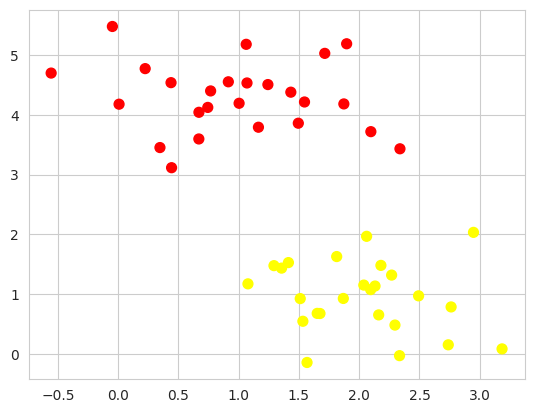

In [5]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

## Viele mögliche Lösungen
Ein linearer diskriminierender Klassifikator würde versuchen, eine gerade Linie zu ziehen, die die beiden Datensätze trennt, und dadurch ein Modell für die Klassifizierung erstellen. Bei zweidimensionalen Daten wie den hier gezeigten ist dies eine Aufgabe, die wir von Hand erledigen könnten. Aber sofort sehen wir ein Problem: Es gibt mehr als eine mögliche Trennlinie, die perfekt zwischen den beiden Klassen unterscheiden kann!

Wir können einige davon wie folgt zeichnen; die folgende Abbildung zeigt das Ergebnis:

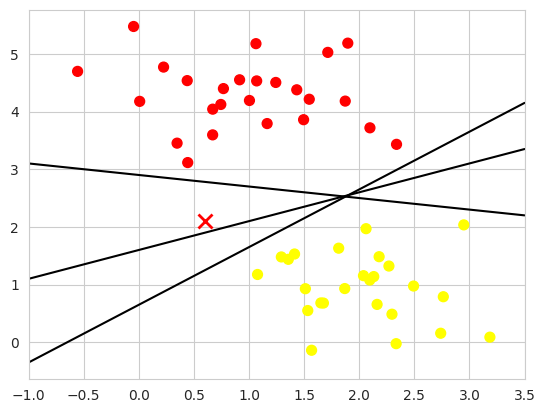

In [6]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);

# Dies sind drei sehr unterschiedliche Trennlinien, die jedoch perfekt zwischen
# diesen Stichproben unterscheiden. Je nachdem, welche Sie wählen, wird einem
# neuen Datenpunkt (z. B. dem in diesem Diagramm mit „X” markierten) eine
# andere Bezeichnung zugewiesen! Offensichtlich reicht unsere einfache
# Intuition, „eine Linie zwischen Klassen zu ziehen”, nicht aus, und wir
# müssen etwas tiefer nachdenken.

# SVMs: Den Randbereich maximieren

Support-Vektor-Maschinen bieten eine Möglichkeit, dies zu verbessern. Die Idee dahinter ist folgende: Anstatt einfach eine Linie ohne Breite zwischen den Klassen zu ziehen, können wir um jede Linie herum einen Rand mit einer bestimmten Breite (Margin) bis zum nächstgelegenen Punkt zeichnen. Hier ist ein Beispiel, wie dies aussehen könnte (siehe folgende Abbildung):

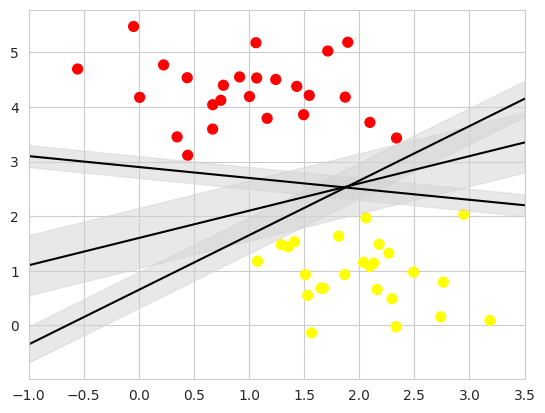

In [7]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='lightgray', alpha=0.5)

plt.xlim(-1, 3.5);

# Visualisierung der "Margins" für die drei möglichen Trennlinien
# Wir wählen die Gerade mit dem breitesten Randbereich als optimales Modell

## Anpassen einer SVM

Sehen wir uns das Ergebnis einer tatsächlichen Anpassung an diese Daten an: Wir verwenden den Support-Vektor-Klassifikator (SVC) von Scikit-Learn, um ein SVM-Modell für diese Daten zu trainieren. Vorläufig verwenden wir einen linearen Kernel und setzen den C-Parameter auf einen sehr großen Wert (wir werden die Bedeutung dieser Parameter gleich näher erläutern):

In [8]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

In [9]:
# kleine Hilfsfunktion, um die SVM Entscheidungsgrenzen zu plotten

def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, edgecolors='black',
                   facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

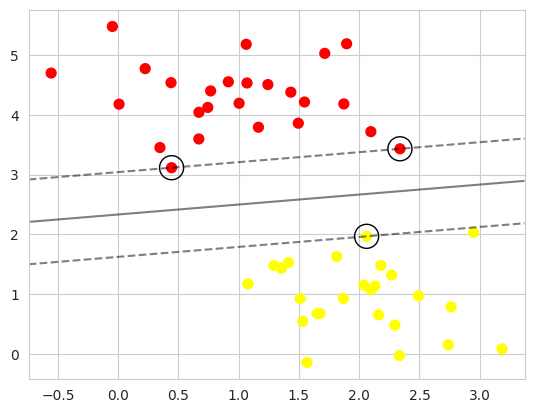

In [10]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model);

# Die Gerade ist die Trennlinie, die den Margin zwischen den beiden Punktmengen maximiert
# die schwarz eingekreisten Punkte sind die entscheidenen Punkte für das optimale Modell
# Sie werden als "Stützvektoren" bzw. "Support Vectors" bezeichnet

In [11]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

Ein Schlüssel zum Erfolg dieses Klassifikators ist, dass für die Anpassung nur die Positionen der Stützvektoren von Bedeutung sind; alle Punkte, die weiter vom Rand entfernt sind und sich auf der richtigen Seite befinden, verändern die Anpassung nicht. Technisch gesehen liegt das daran, dass diese Punkte nicht zur Verlustfunktion beitragen, die zur Anpassung des Modells verwendet wird, sodass ihre Position und Anzahl keine Rolle spielen, solange sie den Rand nicht überschreiten.

Dies lässt sich beispielsweise erkennen, wenn wir das aus den ersten 60 Punkten und den ersten 120 Punkten dieses Datensatzes gelernte Modell grafisch darstellen (siehe folgende Abbildung):

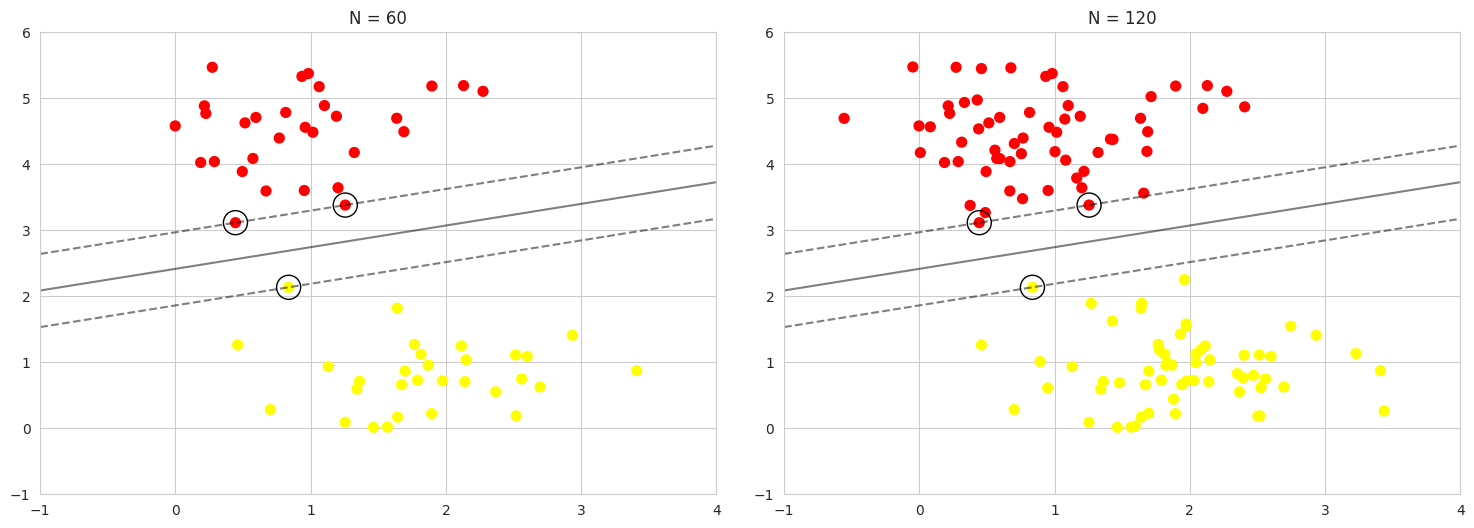

In [12]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

# Im linken Feld sehen wir das Modell für 60 Trainingspunkte.
# Im rechten Feld sehen wir das Modell für 120 Trainingspunkte.
# Aber: Das Modell hat sich nicht verändert.
# Diese Unempfindlichkeit des Modells gegenüber dem Verhalten
# entfernter Punkte ist eine der Stärken von SVM-Modellen

### Live: Bei Nutzung der IPython interaktiven Widgets, kann man dieses Feature des SVM-Modells gut erkennen.

In [13]:
from ipywidgets import interact, fixed
# Hinweis: ipywidgets sind interaktiv und benötigen eine Live-Kernel-Verbindung.
# Sie funktionieren einwandfrei in einer Live-Colab-Sitzung oder -Präsentation.
# Bei einem statischen Export (z.B. PDF, HTML-Folien) geht die Interaktivität des Widgets verloren.
interact(plot_svm, N=(10, 200), ax=fixed(None));

interactive(children=(IntSlider(value=10, description='N', max=200, min=10), Output()), _dom_classes=('widget-…

# Jenseits linearer Grenzen: Kernel-SVM

Eine Kombination mit einem sogenannten "Kernel" kann eine SVM besonders leistungsfähig machen.

In [ ]:
# Betrachten wir einige Daten, die nicht linear trennbar sind.

from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

# Ein linearer Klassifikator kann diese Daten nicht trennen.

In [ ]:
# Der Code in dieser Zelle führt eine einfache Projektion der Daten X in eine
# höhere Dimension durch, um sie möglicherweise linear trennbar zu machen.
# Dies ist ein Konzept, das dem sogenannten 'Kernel-Trick' zugrunde liegt,
# Eine einfach Projektion ist insbesondere die zentrierte radiale Basisfunktion
# (RBF)

r = np.exp(-(X ** 2).sum(1))

### RBF-Funktion in LaTeX

Die Formel für die radiale Basisfunktion (RBF) lautet:

$$r = \exp(-(x^2 + y^2))$$

Diese Transformation bildet die ursprünglichen 2D-Daten in einen 1D-Wert ab, der eine radiale Entfernung vom Ursprung darstellt. Punkte, die näher am Ursprung liegen, erhalten einen höheren r-Wert. Wenn man diese neue Dimension zusammen mit den ursprünglichen x und y visualisiert (wie in der nächsten Zelle geschehen), kann man sehen, dass die Daten in diesem 3D-Raum linear trennbar werden.

In [ ]:
from mpl_toolkits import mplot3d

ax = plt.subplot(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
ax.view_init(elev=20, azim=30)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('r');

# mit einem dreidimensionalen Diagramm können wir die zusätzliche Dimension
# visualisieren.

# Wir können sehen, dass die Daten mit dieser zusätzlichen Dimension trivial linear trennbar werden, indem wir eine Trennebene beispielsweise bei r=0,7 zeichnen.
# In diesem Fall mussten wir unsere Projektion sorgfältig auswählen und abstimmen:
# Hätten wir unsere radiale Basisfunktion nicht an der richtigen Stelle zentriert, hätten wir keine so sauberen, linear trennbaren Ergebnisse erhalten.
# Im Allgemeinen ist die Notwendigkeit, eine solche Wahl zu treffen, ein Problem: Wir möchten irgendwie automatisch die besten Basisfunktionen finden, die wir verwenden können.

## Der Kernel-Trick
In einfachen Worten ist der Kernel-Trick eine clevere Methode, die SVMs verwenden, um auch nicht-linear trennbare Daten zu klassifizieren, ohne die Daten tatsächlich in einen höherdimensionalen Raum zu projizieren.

Stellen Sie sich vor, Sie haben Datenpunkte, die in zwei Dimensionen nicht durch eine gerade Linie getrennt werden können (z.B. konzentrische Kreise). Der Kernel-Trick macht Folgendes:


1.   "Als ob" in höherer Dimension: Er berechnet, wie die Ähnlichkeit oder der Abstand zwischen Datenpunkten aussehen würde, wenn sie in einen viel höherdimensionalen Raum abgebildet wären. Er tut dies, ohne die Abbildung selbst tatsächlich durchzuführen.
2.   Lineare Trennung möglich: In diesem "virtuell" höherdimensionalen Raum sind die Datenpunkte dann linear trennbar – man kann eine einfache Ebene (oder Hyperebene) finden, die die Klassen trennt.


Der Trick ist, dass wir die teure und rechenintensive explizite Transformation der Daten in den neuen Raum vermeiden. Stattdessen verwenden wir eine Kernel-Funktion (wie den RBF-Kernel), die direkt die Ähnlichkeit der Punkte im höherdimensionalen Raum berechnet. Das spart Rechenzeit und ermöglicht es SVMs, komplexe Entscheidungsgrenzen zu lernen.

In [ ]:
# wir ersetzen den linearen Kernel des Modell durch einen RBF-Kernel

clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

# Diese Kernel-Transformationsstrategie wird häufig im maschinellen Lernen
# verwendet, um aus schnellen linearen Methoden schnelle nichtlineare Methoden
# zu machen

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

# an die Daten angepasste Kernel-SVM

# Aufweichung der Margins
Häufig finden sich jedoch in den Daten Überschneidungen. Was können wir dann tun?

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

# Daten mit einigen Überschneidungen

## Soft-Margin mit Schummelfaktor
Um diesen Fall zu behandeln, verfügt die SVM-Implementierung über einen gewissen Schummel-Faktor, der den Rand „aufweicht“: Das heißt, sie lässt einige Punkte in den Rand hineinrutschen, wenn dadurch eine bessere Anpassung erzielt wird. Die Härte des Spielraums wird durch einen Abstimmungsparameter gesteuert, der meist als C bezeichnet wird. Bei einem sehr großen C ist der Spielraum hart und Punkte können nicht darin liegen. Bei einem kleineren C ist der Spielraum weicher und kann wachsen, um einige Punkte zu umfassen.

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

# Auswirkung des Parameters C auf den Stützvektor-Fit

# Der optimale Wert von C ist von der Datenmenge abhängig und
# kann zum Beispiel durch Kreuz-Validierung ermittelt werden.